# Imports

In [823]:
!pip install featurewiz

In [824]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import joblib
plt.style.use('ggplot')
pd.set_option('display.max_columns', 200) # to see all output of spreadsheet

# Original Dataset
These datasets consist of basketball statistics from NBA, BAA, and ABA leagues. "Team Stats Per Game.csv" measures offensive skills and "Opponent Stats Per Game.csv" measures defensive skills. Both measure per-game averages for a team over a season.

## Labels from "Team Stats Per Game.csv"
season : year the season took place (Possible Values: 1947-2026) (Ex. 2026 refers to the current 2025-2026 season)\
lg : league/association (Possible Values: NBA, ABA, BAA)\
team : full team name (Possible Values: 97 unique team names) (1)(2)\
abbreviation : abbreviated version of team name\
playoffs : boolean value indicating whether the team made it to the post-season tournaments (3)(4)\
g : total games played by the team in the season (5)\
mp_per_game : minutes played per game (240 is usually the standard)\
fg_per_game : field goals made per game\
fga_per_game : field goal attempts per game\
fg_percent : field goal percentage (accuracy)\
x3p_per_game : 3-pointers made per game\
x3pa_per_game : 3-pointer attempts per game\
x3p_percent : 3-point shooting percentage (accuracy)\
x2p_per_game : 2-pointers made\
x2pa_per_game : 2-pointer attempts\
x2p_percent : 2-point shooting percentage (accuracy)\
ft_per_game : free throws made\
fta_per_game : free throw attempts\
ft_percent : free throw percentage (accuracy)\
orb_per_game : offensive rebounds\
drb_per_game : defensive rebounds\
trb_per_game : total rebounds\
ast_per_game : assists\
stl_per_game : steals\
blk_per_game : blocks\
tov_per_game : turnovers\
pf_per_game : personal fouls\
pts_per_game : total points scored per game

## Labels from "Opponent Stats Per Game.csv"
"Opponent Stats Per Game.csv" includes the same labels but with "opp_" added to the beginning to indicate opponent statistics.

## Footnotes
(1) Since this dataset spans from 1947-2026, this includes all defunct teams, and teams who have since changed their names. There are currently only 30 active NBA teams.\
(2) This label also includes a value "Team League" for the average statistics for all teams for the entire season\
(3) This includes teams who made it to the Play-In Tournaments, which is why there are 20 teams marked as TRUE per season for this label, when the official playoffs are usually only 16 teams.\
(4) Since the 2026 season is ongoing, 'playoffs' is automatically marked FALSE for all teams\
(5) Usually each team plays 82 games, however there are outliers. (During COVID, many games were dropped. Also the NBA has had 'lockout" seasons where they ended early due to union disagreements).



In [825]:
from pandas.core.reshape import merge
team_df = pd.read_csv('https://raw.githubusercontent.com/sumitrodatta/bball-reference-datasets/refs/heads/master/Data/Team%20Stats%20Per%20Game.csv')
opp_df = pd.read_csv('https://raw.githubusercontent.com/sumitrodatta/bball-reference-datasets/refs/heads/master/Data/Opponent%20Stats%20Per%20Game.csv')

# merging the datasets
common_columns = ['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game']
merged_df = pd.merge(team_df, opp_df, on=common_columns)

#Transform into net values rather than having team and opp values
#I know there's a more efficient way to do this but I hate python syntax shenanigans so take this hardcoded blob
merged_df['net_fg_per_game'] = merged_df['fg_per_game'] - merged_df['opp_fg_per_game']
merged_df['net_fga_per_game'] = merged_df['fga_per_game'] - merged_df['opp_fga_per_game']
merged_df['net_fg_percent'] = merged_df['fg_percent'] - merged_df['opp_fg_percent']
merged_df['net_x3p_per_game'] = merged_df['x3p_per_game'] - merged_df['opp_x3p_per_game']
merged_df['net_x3pa_per_game'] = merged_df['x3pa_per_game'] - merged_df['opp_x3pa_per_game']
merged_df['net_x3p_percent'] = merged_df['x3p_percent'] - merged_df['opp_x3p_percent']
merged_df['net_x2p_per_game'] = merged_df['x2p_per_game'] - merged_df['opp_x2p_per_game']
merged_df['net_x2pa_per_game'] = merged_df['x2pa_per_game'] - merged_df['opp_x2pa_per_game']
merged_df['net_x2p_percent'] = merged_df['x2p_percent'] - merged_df['opp_x2p_percent']
merged_df['net_ft_per_game'] = merged_df['ft_per_game'] - merged_df['opp_ft_per_game']
merged_df['net_fta_per_game'] = merged_df['fta_per_game'] - merged_df['opp_fta_per_game']
merged_df['net_ft_percent'] = merged_df['ft_percent'] - merged_df['opp_ft_percent']
merged_df['net_orb_per_game'] = merged_df['orb_per_game'] - merged_df['opp_orb_per_game']
merged_df['net_drb_per_game'] = merged_df['drb_per_game'] - merged_df['opp_drb_per_game']
merged_df['net_trb_per_game'] = merged_df['trb_per_game'] - merged_df['opp_trb_per_game']
merged_df['net_ast_per_game'] = merged_df['ast_per_game'] - merged_df['opp_ast_per_game']
merged_df['net_stl_per_game'] = merged_df['stl_per_game'] - merged_df['opp_stl_per_game']
merged_df['net_blk_per_game'] = merged_df['blk_per_game'] - merged_df['opp_blk_per_game']
merged_df['net_tov_per_game'] = merged_df['tov_per_game'] - merged_df['opp_tov_per_game']
merged_df['net_pf_per_game'] = merged_df['pf_per_game'] - merged_df['opp_pf_per_game']

cols_to_drop = merged_df.loc[:, 'fg_per_game':'pf_per_game'].columns
merged_df = merged_df.drop(columns=cols_to_drop)
cols_to_drop = merged_df.loc[:, 'opp_fg_per_game':'opp_pf_per_game'].columns
merged_df = merged_df.drop(columns=cols_to_drop)

# add column for point differential
merged_df['point_diff'] = merged_df['pts_per_game'] - merged_df['opp_pts_per_game']

#These should probably be dropped as well, since point_diff is our actual dependent variable. I'm only commenting this so that I remember that I removed them
cols_to_drop = merged_df.loc[:, 'pts_per_game':'opp_pts_per_game'].columns
merged_df = merged_df.drop(columns=cols_to_drop)

# save into new .csv file
merged_df.to_csv('Full_Basketball_Stats.csv', index=False)

#Sort by season in increasing order instead of decreasing.
merged_df = merged_df.sort_values(by=['season', 'team'])


In [826]:
merged_df.shape

(1907, 28)

In [827]:
merged_df.head()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
1895,1947,BAA,Boston Celtics,BOS,False,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-4.9
1896,1947,BAA,Chicago Stags,CHS,True,61.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.7
1897,1947,BAA,Cleveland Rebels,CLR,True,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.9
1898,1947,BAA,Detroit Falcons,DTF,False,60.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.0
1906,1947,BAA,League Average,NaN,False,60.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0


In [828]:
merged_df.tail()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
25,2026,NBA,Sacramento Kings,SAC,False,61.0,241.2,-3.1,0.0,-0.035,-2.9,-5.5,-0.028,-0.3,5.5,-0.059,-1.6,-1.8,-0.008,-0.1,-3.1,-3.2,-2.5,-0.2,-0.3,0.1,1.4,-10.7
26,2026,NBA,San Antonio Spurs,SAS,False,59.0,240.4,1.5,-1.6,0.026,0.3,1.3,-0.005,1.2,-2.9,0.053,3.3,4.4,-0.007,0.6,2.6,3.2,0.6,0.1,0.8,0.2,-1.8,6.8
27,2026,NBA,Toronto Raptors,TOR,False,60.0,241.7,2.2,2.7,0.011,-1.4,-3.9,-0.002,3.7,6.6,0.002,-1.1,-1.2,-0.011,0.1,-0.8,-0.6,4.6,0.6,-0.4,-2.1,1.4,2.0
28,2026,NBA,Utah Jazz,UTA,False,60.0,242.5,-2.4,-0.6,-0.023,-2.7,-4.4,-0.026,0.3,3.8,-0.038,-0.5,-1.4,0.020,0.1,-1.3,-1.2,-0.7,-0.7,-2.5,1.6,1.1,-7.9
29,2026,NBA,Washington Wizards,WAS,False,59.0,240.8,-2.7,-2.1,-0.018,-1.4,-2.3,-0.013,-1.4,0.2,-0.027,-4.2,-4.6,-0.022,-1.8,-2.8,-4.6,-3.6,-2.0,0.6,1.8,3.4,-10.8


In [829]:
merged_df.columns

Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game',
       'net_fg_per_game', 'net_fga_per_game', 'net_fg_percent',
       'net_x3p_per_game', 'net_x3pa_per_game', 'net_x3p_percent',
       'net_x2p_per_game', 'net_x2pa_per_game', 'net_x2p_percent',
       'net_ft_per_game', 'net_fta_per_game', 'net_ft_percent',
       'net_orb_per_game', 'net_drb_per_game', 'net_trb_per_game',
       'net_ast_per_game', 'net_stl_per_game', 'net_blk_per_game',
       'net_tov_per_game', 'net_pf_per_game', 'point_diff'],
      dtype='object')

In [830]:
merged_df.dtypes

,0
season,int64
lg,object
team,object
abbreviation,object
playoffs,bool
g,float64
mp_per_game,float64
net_fg_per_game,float64
net_fga_per_game,float64
net_fg_percent,float64


In [831]:
merged_df.describe()

,season,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
count,1907.000000,1906.000000,1717.000000,1669.000000,1667.000000,1666.000000,1464.000000,1464.000000,1464.000000,1669.000000,1667.000000,1667.000000,1669.000000,1668.000000,1667.000000,1544.000000,1544.000000,1663.000000,1667.000000,1519.000000,1519.000000,1647.000000,1669.000000,1906.000000
mean,1993.349240,79.208814,241.608561,-0.003535,0.000420,0.000070,-0.000342,0.000956,-0.003650,-0.002217,0.000900,0.000227,-0.000899,-0.001319,0.000193,0.001813,-0.000453,0.001143,-0.004379,-0.002370,0.000395,0.000668,0.002636,-0.005089
std,20.982797,7.224735,0.827268,1.922873,2.863961,0.023019,1.342820,3.274406,0.036456,2.217659,4.196983,0.025854,2.400925,2.978785,0.027989,1.496709,2.108138,2.736759,2.330393,1.075715,1.126680,1.544175,1.672393,4.471992
min,1947.000000,11.000000,237.700000,-5.900000,-9.100000,-0.073000,-4.100000,-10.900000,-0.228000,-7.200000,-14.900000,-0.084000,-10.000000,-11.000000,-0.115000,-7.000000,-6.500000,-9.700000,-7.000000,-3.300000,-4.300000,-5.300000,-5.700000,-15.200000
25%,1976.500000,82.000000,241.000000,-1.200000,-1.700000,-0.015000,-0.700000,-1.800000,-0.022000,-1.400000,-2.600000,-0.017000,-1.500000,-2.000000,-0.017000,-1.000000,-1.400000,-1.800000,-1.600000,-0.700000,-0.700000,-1.000000,-1.100000,-2.900000
50%,1995.000000,82.000000,241.500000,0.000000,0.000000,0.000000,0.000000,-0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2011.000000,82.000000,242.100000,1.300000,1.800000,0.015000,0.700000,1.800000,0.017000,1.500000,2.700000,0.016000,1.500000,1.925000,0.019000,1.000000,1.500000,1.800000,1.500000,0.700000,0.700000,1.000000,1.100000,3.100000
max,2026.000000,84.000000,244.900000,6.700000,11.700000,0.085000,6.000000,15.600000,0.150000,7.900000,14.900000,0.110000,7.800000,10.500000,0.102000,5.700000,6.700000,11.800000,7.700000,4.400000,3.800000,5.500000,5.900000,12.900000


In [832]:
unique_teams = sorted(merged_df['team'].unique())
print(f"There are {len(unique_teams)} unique team labels:\n")
for team in unique_teams:
    print(team)

There are 97 unique team labels:

Anaheim Amigos
Anderson Packers
Atlanta Hawks
Baltimore Bullets
Boston Celtics
Brooklyn Nets
Buffalo Braves
Capital Bullets
Carolina Cougars
Charlotte Bobcats
Charlotte Hornets
Chicago Bulls
Chicago Packers
Chicago Stags
Chicago Zephyrs
Cincinnati Royals
Cleveland Cavaliers
Cleveland Rebels
Dallas Chaparrals
Dallas Mavericks
Denver Nuggets
Denver Rockets
Detroit Falcons
Detroit Pistons
Fort Wayne Pistons
Golden State Warriors
Houston Mavericks
Houston Rockets
Indiana Pacers
Indianapolis Jets
Indianapolis Olympians
Kansas City Kings
Kansas City-Omaha Kings
Kentucky Colonels
League Average
Los Angeles Clippers
Los Angeles Lakers
Los Angeles Stars
Memphis Grizzlies
Memphis Pros
Memphis Sounds
Memphis Tams
Miami Floridians
Miami Heat
Milwaukee Bucks
Milwaukee Hawks
Minneapolis Lakers
Minnesota Muskies
Minnesota Pipers
Minnesota Timberwolves
New Jersey Americans
New Jersey Nets
New Orleans Buccaneers
New Orleans Hornets
New Orleans Jazz
New Orleans Pelicans

# Cleaning the Dataset
- only include NBA games
- remove "League Average" statistics, since this information is already in the dataset
- only include the years 1980 - present (Since many statistics like 3 pointers weren't introduced until the 1980s)
- check for duplicates
- check for NaN values
- deal with name changes for teams over the years

In [833]:
# only keep NBA games
NBA_merged_df = merged_df[merged_df['lg'] == 'NBA']

In [834]:
# remove League Average statistics
NBA_merged_df = NBA_merged_df[NBA_merged_df['team'] != 'League Average']

In [835]:
# only 1980 to present
NBA_merged_df = NBA_merged_df[NBA_merged_df['season'] >= 1980]

In [836]:
# remove 2026. to be used as unseen data
unseen_df = NBA_merged_df[NBA_merged_df['season'] == 2026]
NBA_merged_df = NBA_merged_df[NBA_merged_df['season'] != 2026]
NBA_merged_df.tail()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
56,2025,NBA,Sacramento Kings,SAC,True,82.0,242.4,1.4,2.3,0.004,-1.9,-3.0,-0.024,3.5,5.3,0.010,-0.5,-1.2,0.023,1.0,0.8,1.9,-0.5,-0.3,0.1,-0.6,0.4,0.4
57,2025,NBA,San Antonio Spurs,SAS,False,82.0,240.6,-2.0,-2.7,-0.009,-0.3,0.3,-0.008,-1.8,-3.0,-0.003,1.6,2.5,-0.016,-1.2,-1.4,-2.5,0.6,0.1,1.2,0.2,-0.8,-2.8
58,2025,NBA,Toronto Raptors,TOR,False,82.0,241.5,0.4,2.7,-0.008,-1.4,-3.7,-0.001,1.8,6.4,-0.031,-3.8,-4.1,-0.030,1.1,-1.0,0.1,2.6,-1.1,-1.7,0.2,3.1,-4.3
59,2025,NBA,Utah Jazz,UTA,False,82.0,241.5,-4.3,-4.3,-0.026,-0.9,-1.7,-0.008,-3.3,-2.7,-0.037,0.1,-0.2,0.011,0.3,0.8,1.2,-4.1,-3.0,-2.0,5.4,-0.4,-9.3
60,2025,NBA,Washington Wizards,WAS,False,82.0,240.6,-4.3,-2.9,-0.032,-1.2,-0.1,-0.029,-3.1,-2.9,-0.030,-2.8,-3.1,-0.015,-2.3,-2.9,-5.2,-3.4,-1.5,-0.1,2.3,1.5,-12.4


In [837]:
# check for duplicate rows
NBA_merged_df.loc[merged_df.duplicated()]

,season,lg,team,abbreviation,playoffs,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff


In [838]:
# check for null values
NBA_merged_df.isna().sum()

,0
season,0
lg,0
team,0
abbreviation,0
playoffs,0
g,0
mp_per_game,0
net_fg_per_game,0
net_fga_per_game,0
net_fg_percent,0


In [839]:
unique_NBA_teams = sorted(NBA_merged_df['team'].unique())
print(f"There are {len(unique_NBA_teams)} unique NBA team labels:\n")
for team in unique_NBA_teams:
    print(team)

There are 39 unique NBA team labels:

Atlanta Hawks
Boston Celtics
Brooklyn Nets
Charlotte Bobcats
Charlotte Hornets
Chicago Bulls
Cleveland Cavaliers
Dallas Mavericks
Denver Nuggets
Detroit Pistons
Golden State Warriors
Houston Rockets
Indiana Pacers
Kansas City Kings
Los Angeles Clippers
Los Angeles Lakers
Memphis Grizzlies
Miami Heat
Milwaukee Bucks
Minnesota Timberwolves
New Jersey Nets
New Orleans Hornets
New Orleans Pelicans
New Orleans/Oklahoma City Hornets
New York Knicks
Oklahoma City Thunder
Orlando Magic
Philadelphia 76ers
Phoenix Suns
Portland Trail Blazers
Sacramento Kings
San Antonio Spurs
San Diego Clippers
Seattle SuperSonics
Toronto Raptors
Utah Jazz
Vancouver Grizzlies
Washington Bullets
Washington Wizards


In [840]:
# dealing with name changes
team_mapping = {
    'Seattle SuperSonics': 'Oklahoma City Thunder',
    'New Jersey Nets': 'Brooklyn Nets',
    'Vancouver Grizzlies': 'Memphis Grizzlies',
    'San Diego Clippers': 'Los Angeles Clippers',
    'New Orleans Hornets': 'New Orleans Pelicans',
    'New Orleans/Oklahoma City Hornets': 'New Orleans Pelicans',
    'Charlotte Bobcats': 'Charlotte Hornets',
    'Washington Bullets': 'Washington Wizards',
    'Kansas City Kings': 'Sacramento Kings'
}

NBA_merged_df['team'] = NBA_merged_df['team'].replace(team_mapping)

unique_NBA_teams = sorted(NBA_merged_df['team'].unique())
print(f"There are {len(unique_NBA_teams)} unique NBA team labels:\n")
for team in unique_NBA_teams:
    print(team)

There are 30 unique NBA team labels:

Atlanta Hawks
Boston Celtics
Brooklyn Nets
Charlotte Hornets
Chicago Bulls
Cleveland Cavaliers
Dallas Mavericks
Denver Nuggets
Detroit Pistons
Golden State Warriors
Houston Rockets
Indiana Pacers
Los Angeles Clippers
Los Angeles Lakers
Memphis Grizzlies
Miami Heat
Milwaukee Bucks
Minnesota Timberwolves
New Orleans Pelicans
New York Knicks
Oklahoma City Thunder
Orlando Magic
Philadelphia 76ers
Phoenix Suns
Portland Trail Blazers
Sacramento Kings
San Antonio Spurs
Toronto Raptors
Utah Jazz
Washington Wizards


In [841]:
# fix corresponding abbreviations
unique_NBA_abbr = sorted(NBA_merged_df['abbreviation'].unique())
print(f"There are {len(unique_NBA_abbr)} unique NBA abbreviation labels:\n")
for abbreviation in unique_NBA_abbr:
    print(abbreviation)

There are 40 unique NBA abbreviation labels:

ATL
BOS
BRK
CHA
CHH
CHI
CHO
CLE
DAL
DEN
DET
GSW
HOU
IND
KCK
LAC
LAL
MEM
MIA
MIL
MIN
NJN
NOH
NOK
NOP
NYK
OKC
ORL
PHI
PHO
POR
SAC
SAS
SDC
SEA
TOR
UTA
VAN
WAS
WSB


In [842]:
abbr_mapping = {
    'SEA': 'OKC',
    'NJN': 'BRK',
    'VAN': 'MEM',
    'WSB': 'WAS',
    'KCK': 'SAC',
    'CHH': 'NOP',
    'NOH': 'NOP',
    'NOK': 'NOP',
    'CHA': 'CHO',
    'SDC': 'LAC'
}

NBA_merged_df['abbreviation'] = NBA_merged_df['abbreviation'].replace(abbr_mapping)

In [843]:
# fixing the double abbreviations for the Charlotte Hornets (complicated history)
NBA_merged_df.loc[(NBA_merged_df['team'] == 'Charlotte Hornets') & (NBA_merged_df['abbreviation'] == 'NOP'), 'team'] = 'New Orleans Pelicans'
NBA_merged_df.loc[NBA_merged_df['team'] == 'Charlotte Hornets', 'abbreviation'] = 'CHO'

In [844]:
print(NBA_merged_df[['team', 'abbreviation']].drop_duplicates().sort_values('team'))

                        team abbreviation
1338           Atlanta Hawks          ATL
1339          Boston Celtics          BOS
1350           Brooklyn Nets          BRK
653        Charlotte Hornets          CHO
1340           Chicago Bulls          CHI
1341     Cleveland Cavaliers          CLE
1318        Dallas Mavericks          DAL
1342          Denver Nuggets          DEN
1343         Detroit Pistons          DET
1344   Golden State Warriors          GSW
1345         Houston Rockets          HOU
1346          Indiana Pacers          IND
1356    Los Angeles Clippers          LAC
1348      Los Angeles Lakers          LAL
949        Memphis Grizzlies          MEM
1133              Miami Heat          MIA
1349         Milwaukee Bucks          MIL
1107  Minnesota Timberwolves          MIN
1122    New Orleans Pelicans          NOP
1351         New York Knicks          NYK
1357   Oklahoma City Thunder          OKC
1110           Orlando Magic          ORL
1352      Philadelphia 76ers      

In [845]:
# save the cleaned dataset
NBA_merged_df.to_csv('Cleaned_NBA_Stats.csv', index=False)

# Cleaned Dataset Attributes

In [846]:
NBA_merged_df.shape

(1284, 28)

In [847]:
NBA_merged_df.head()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
1338,1980,NBA,Atlanta Hawks,ATL,True,82.0,241.2,1.5,1.9,0.006,-0.4,-1.3,-0.078,1.8,3.2,0.004,0.5,0.4,0.006,1.3,0.8,2.1,1.9,1.2,-0.2,-2.0,1.5,2.9
1339,1980,NBA,Boston Celtics,BOS,True,82.0,242.4,2.2,0.9,0.020,1.1,1.9,0.098,1.1,-1.1,0.019,2.4,2.8,0.009,0.8,2.0,2.7,4.0,1.5,-1.3,-1.1,-1.0,7.8
1340,1980,NBA,Chicago Bulls,CHI,False,82.0,242.7,-2.7,-3.4,-0.012,0.2,1.0,-0.016,-3.0,-4.3,-0.009,2.5,2.8,0.011,-0.5,1.5,1.0,0.5,-1.7,-1.3,1.7,-0.7,-2.7
1341,1980,NBA,Cleveland Cavaliers,CLE,False,82.0,243.0,0.0,5.3,-0.027,-0.4,-0.4,-0.098,0.3,5.7,-0.026,0.7,0.7,0.007,0.9,-3.2,-2.2,-1.2,0.7,-1.8,-3.6,-1.2,0.3
1342,1980,NBA,Denver Nuggets,DEN,False,82.0,241.8,-3.4,-1.5,-0.029,0.1,0.5,-0.002,-3.5,-2.0,-0.029,2.1,3.7,-0.023,1.4,-0.7,0.7,-2.5,-0.8,-0.6,1.2,-1.4,-4.4


In [848]:
NBA_merged_df.tail()

,season,lg,team,abbreviation,playoffs,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
56,2025,NBA,Sacramento Kings,SAC,True,82.0,242.4,1.4,2.3,0.004,-1.9,-3.0,-0.024,3.5,5.3,0.010,-0.5,-1.2,0.023,1.0,0.8,1.9,-0.5,-0.3,0.1,-0.6,0.4,0.4
57,2025,NBA,San Antonio Spurs,SAS,False,82.0,240.6,-2.0,-2.7,-0.009,-0.3,0.3,-0.008,-1.8,-3.0,-0.003,1.6,2.5,-0.016,-1.2,-1.4,-2.5,0.6,0.1,1.2,0.2,-0.8,-2.8
58,2025,NBA,Toronto Raptors,TOR,False,82.0,241.5,0.4,2.7,-0.008,-1.4,-3.7,-0.001,1.8,6.4,-0.031,-3.8,-4.1,-0.030,1.1,-1.0,0.1,2.6,-1.1,-1.7,0.2,3.1,-4.3
59,2025,NBA,Utah Jazz,UTA,False,82.0,241.5,-4.3,-4.3,-0.026,-0.9,-1.7,-0.008,-3.3,-2.7,-0.037,0.1,-0.2,0.011,0.3,0.8,1.2,-4.1,-3.0,-2.0,5.4,-0.4,-9.3
60,2025,NBA,Washington Wizards,WAS,False,82.0,240.6,-4.3,-2.9,-0.032,-1.2,-0.1,-0.029,-3.1,-2.9,-0.030,-2.8,-3.1,-0.015,-2.3,-2.9,-5.2,-3.4,-1.5,-0.1,2.3,1.5,-12.4


In [849]:
NBA_merged_df.columns

Index(['season', 'lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game',
       'net_fg_per_game', 'net_fga_per_game', 'net_fg_percent',
       'net_x3p_per_game', 'net_x3pa_per_game', 'net_x3p_percent',
       'net_x2p_per_game', 'net_x2pa_per_game', 'net_x2p_percent',
       'net_ft_per_game', 'net_fta_per_game', 'net_ft_percent',
       'net_orb_per_game', 'net_drb_per_game', 'net_trb_per_game',
       'net_ast_per_game', 'net_stl_per_game', 'net_blk_per_game',
       'net_tov_per_game', 'net_pf_per_game', 'point_diff'],
      dtype='object')

In [850]:
NBA_merged_df.dtypes

,0
season,int64
lg,object
team,object
abbreviation,object
playoffs,bool
g,float64
mp_per_game,float64
net_fg_per_game,float64
net_fga_per_game,float64
net_fg_percent,float64


In [851]:
NBA_merged_df.describe()

,season,g,mp_per_game,net_fg_per_game,net_fga_per_game,net_fg_percent,net_x3p_per_game,net_x3pa_per_game,net_x3p_percent,net_x2p_per_game,net_x2pa_per_game,net_x2p_percent,net_ft_per_game,net_fta_per_game,net_ft_percent,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
count,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.000000,1284.00000
mean,2003.635514,80.401869,241.673131,-0.002726,0.000156,0.000086,0.000156,0.001480,-0.003236,-0.000312,0.000078,0.000288,-0.001324,-0.000234,0.000189,0.001168,-0.000623,-0.001012,-0.001324,-0.001869,0.000234,0.002882,0.001324,-0.00257
std,12.981233,5.674919,0.836484,1.960650,2.798145,0.023925,1.388557,3.352289,0.036368,2.284728,4.404181,0.027274,2.417813,2.999864,0.029220,1.492336,2.134276,2.710171,2.421958,1.070127,1.149669,1.517890,1.710448,4.68022
min,1980.000000,50.000000,240.000000,-5.900000,-8.300000,-0.073000,-4.100000,-10.900000,-0.228000,-7.200000,-14.900000,-0.084000,-10.000000,-11.000000,-0.115000,-7.000000,-6.500000,-9.700000,-7.000000,-3.300000,-4.300000,-5.300000,-5.700000,-15.20000
25%,1993.000000,82.000000,241.200000,-1.300000,-1.800000,-0.017000,-0.800000,-1.900000,-0.022000,-1.500000,-2.800000,-0.019000,-1.500000,-2.000000,-0.019000,-1.000000,-1.500000,-1.900000,-1.600000,-0.700000,-0.800000,-1.000000,-1.100000,-3.20000
50%,2004.000000,82.000000,241.500000,0.000000,-0.100000,0.000000,-0.100000,-0.200000,-0.001000,0.000000,0.250000,0.000000,0.000000,0.000000,0.001500,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,0.100000,0.30000
75%,2015.000000,82.000000,242.100000,1.400000,1.800000,0.016000,0.700000,1.900000,0.018000,1.600000,2.900000,0.019000,1.600000,2.100000,0.021000,1.000000,1.500000,1.900000,1.600000,0.700000,0.800000,1.000000,1.100000,3.40000
max,2025.000000,82.000000,244.900000,6.700000,11.700000,0.066000,6.000000,15.600000,0.150000,7.900000,14.900000,0.110000,7.800000,9.400000,0.102000,5.700000,6.700000,8.400000,7.700000,4.400000,3.800000,5.400000,5.900000,12.90000


# Feature Analysis

In [852]:
# split the data between 3 eras
# 1980s to 2000s
era_80_00 = NBA_merged_df[(NBA_merged_df['season'] >= 1980) & (NBA_merged_df['season'] < 2000)]

# 2000s to 2020s
era_00_20 = NBA_merged_df[(NBA_merged_df['season'] >= 2000) & (NBA_merged_df['season'] < 2020)]

# 2020s to present
era_20_26 = NBA_merged_df[NBA_merged_df['season'] >= 2020]

print(f"1980-2000 rows: {len(era_80_00)}")
print(f"2000-2020 rows: {len(era_00_20)}")
print(f"2020-2026 rows: {len(era_20_26)}")

1980-2000 rows: 509
2000-2020 rows: 595
2020-2026 rows: 180


## Target Variable Distribution (point_diff)
Throughout all eras, the distribution of point_diff is Normal.

### 1980s to 2000s

In [853]:
skew_value = era_80_00['point_diff'].skew()
print(f"Skewness of Point Differential: {skew_value}")

Skewness of Point Differential: -0.24592701919475765


Text(0, 0.5, 'Count')

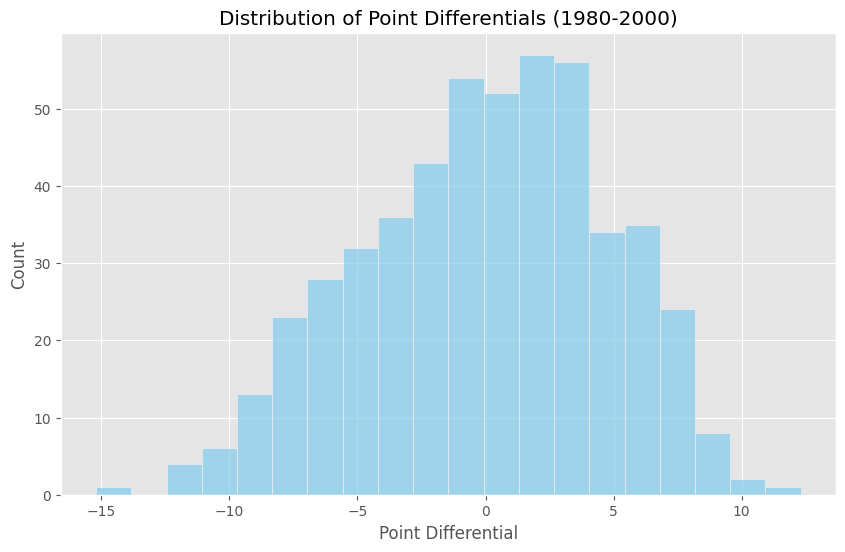

In [854]:
# show the target variable distribution for the dataset
plt.figure(figsize=(10, 6))
sns.histplot(data=era_80_00, x='point_diff', bins=20, color='skyblue')
plt.title('Distribution of Point Differentials (1980-2000)')
plt.xlabel('Point Differential')
plt.ylabel('Count')

### 2000s to 2020s

In [855]:
skew_value = era_00_20['point_diff'].skew()
print(f"Skewness of Point Differential: {skew_value}")

Skewness of Point Differential: -0.17799662886853806


Text(0, 0.5, 'Count')

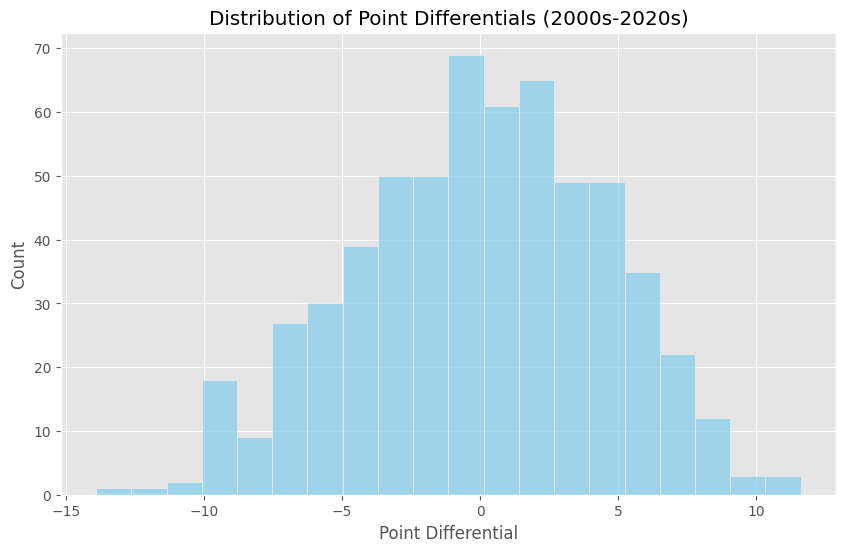

In [856]:
plt.figure(figsize=(10, 6))
sns.histplot(data=era_00_20, x='point_diff', bins=20, color='skyblue')
plt.title('Distribution of Point Differentials (2000s-2020s)')
plt.xlabel('Point Differential')
plt.ylabel('Count')

### 2020s to Present

In [857]:
# calculate skew
skew_value = era_20_26['point_diff'].skew()
print(f"Skewness of Point Differential: {skew_value}")

Skewness of Point Differential: -0.31835081775255947


Text(0, 0.5, 'Count')

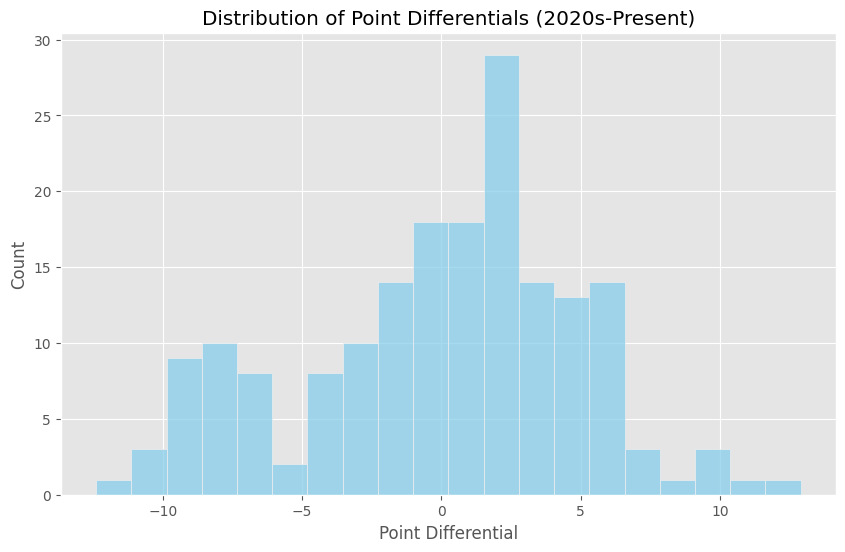

In [858]:
plt.figure(figsize=(10, 6))
sns.histplot(data=era_20_26, x='point_diff', bins=20, color='skyblue')
plt.title('Distribution of Point Differentials (2020s-Present)')
plt.xlabel('Point Differential')
plt.ylabel('Count')

## Correlation Matrix
For 1980-2000, these features are the strongest predictors of point_diff: fg_percent, x2p_percent, opp_x2p_percent, opp_drb_per_game\
For 2000-2020: fg_percent, opp_fg_percent\
For 2020-Present: x3p_percent, pts_per_game, fg_percent, x2p_percent, fg_per_game, opp_blk_per_game, opp_fg_per_game, opp_pts_per_game, opp_x2p_percent, opp_fg_percent

This shows the shift in strategy over the years. In the modern era, teams have shifted towards focusing on 3-pointers, whereas in the past field goals were the focus. This presents a potential conflict when splitting the dataset temporally.

There are more features that are stronger predictors (above 0.5 or below -0.5) for the 2020s-Present era than any other era. This is most likely because this era has a more uniform strategy (since it is a smaller subset of the overall data), thus more predictable. The other eras (1980-2000 and 2000-2020) have less strong predictors since they encompass larger timelines, and thus more strategy shifts over the period.

For feature selection, it is important we select features that are unique to each other to prevent multicollinearity. We can use this heatmap to prevent choosing redundant features.

### 1980s to 2000s

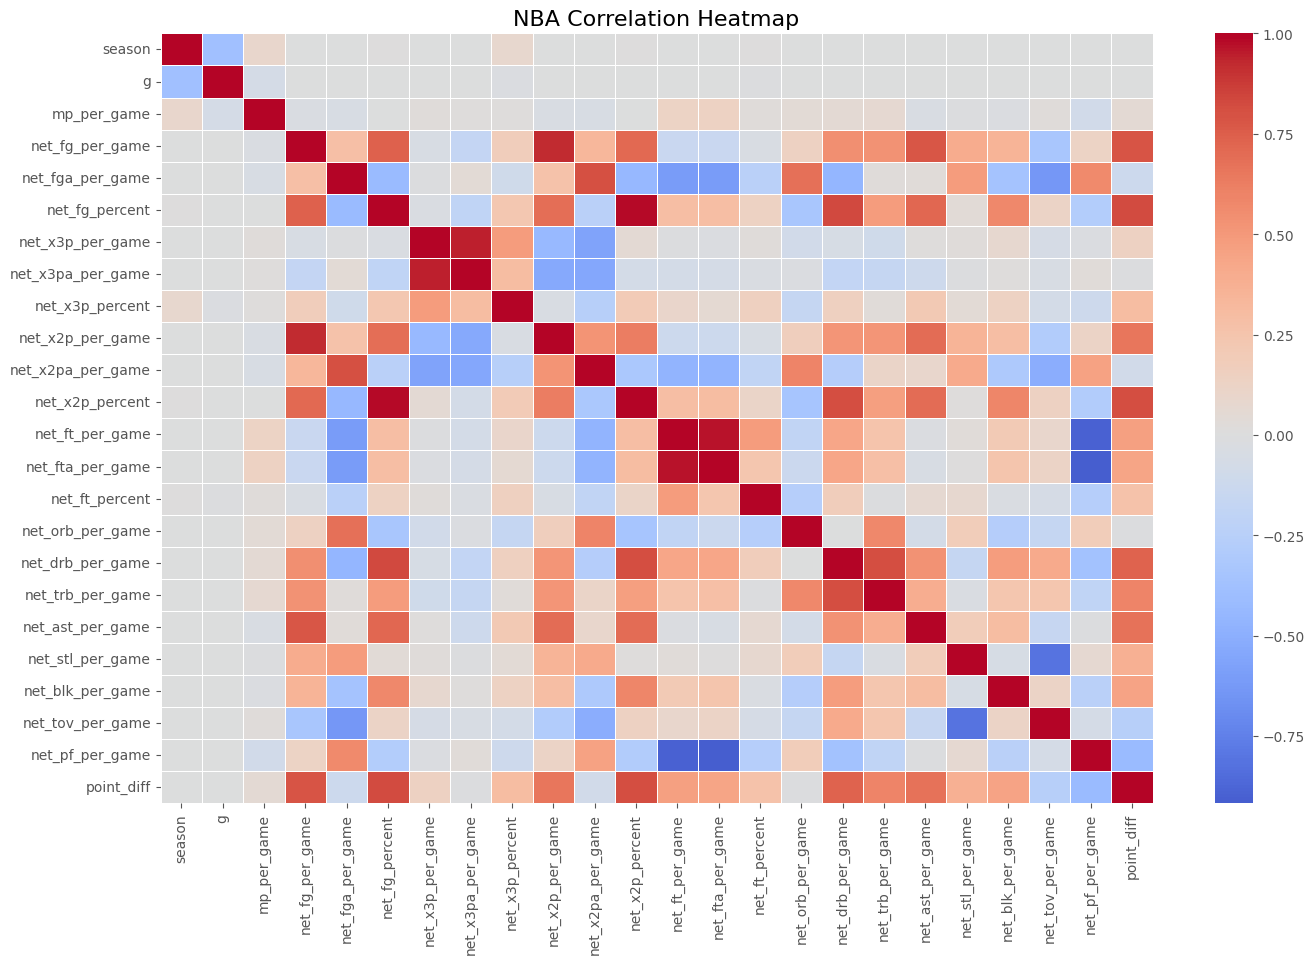

In [859]:
numeric_df = era_80_00.select_dtypes(include=['number'])
corr_matrix_80to00 = numeric_df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix_80to00, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('NBA Correlation Heatmap', fontsize=16)
plt.show()

In [860]:
target_corr = corr_matrix_80to00['point_diff'].sort_values(ascending=False)
print("Numerical Correlation")
print(target_corr)

Numerical Correlation
point_diff           1.000000
net_fg_percent       0.826953
net_x2p_percent      0.816059
net_fg_per_game      0.787823
net_drb_per_game     0.730589
net_ast_per_game     0.676886
net_x2p_per_game     0.656391
net_trb_per_game     0.596522
net_ft_per_game      0.467341
net_blk_per_game     0.450589
net_fta_per_game     0.443543
net_stl_per_game     0.373996
net_x3p_percent      0.300433
net_ft_percent       0.259043
net_x3p_per_game     0.140454
mp_per_game          0.050614
season              -0.000079
g                   -0.000147
net_orb_per_game    -0.004055
net_x3pa_per_game   -0.015406
net_x2pa_per_game   -0.090411
net_fga_per_game    -0.118326
net_tov_per_game    -0.258215
net_pf_per_game     -0.426853
Name: point_diff, dtype: float64


### 2000s to 2020s

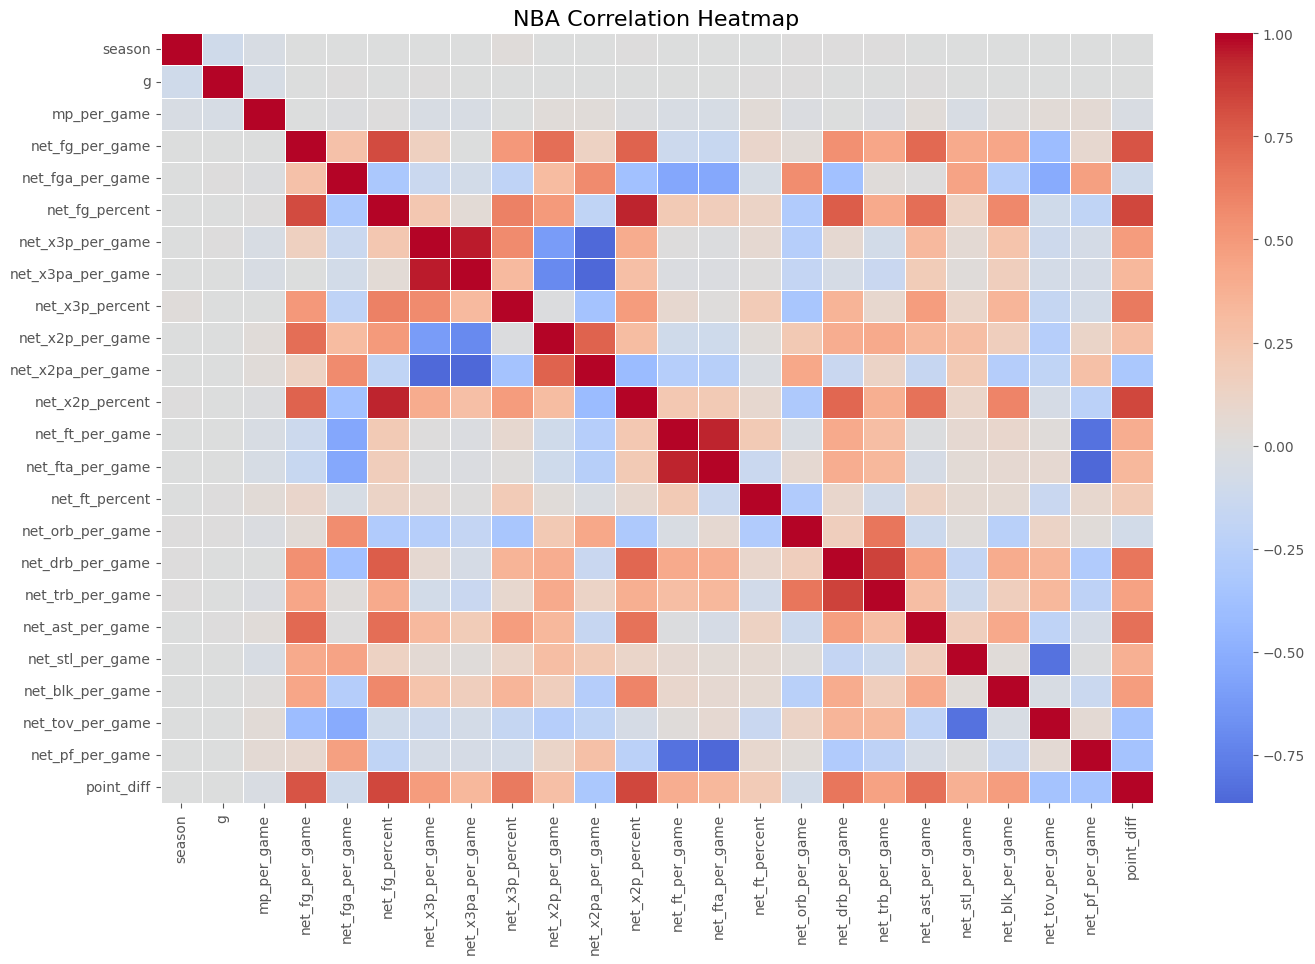

In [861]:
numeric_df = era_00_20.select_dtypes(include=['number'])
corr_matrix_00to20 = numeric_df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix_00to20, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('NBA Correlation Heatmap', fontsize=16)
plt.show()

In [862]:
target_corr = corr_matrix_00to20['point_diff'].sort_values(ascending=False)
print("Numerical Correlation")
print(target_corr)

Numerical Correlation
point_diff           1.000000
net_fg_percent       0.839176
net_x2p_percent      0.838270
net_fg_per_game      0.794837
net_ast_per_game     0.679138
net_drb_per_game     0.658310
net_x3p_percent      0.638356
net_x3p_per_game     0.487923
net_blk_per_game     0.481511
net_trb_per_game     0.456514
net_ft_per_game      0.391644
net_stl_per_game     0.375043
net_x3pa_per_game    0.332153
net_fta_per_game     0.330208
net_x2p_per_game     0.284573
net_ft_percent       0.202785
g                   -0.000319
season              -0.000368
mp_per_game         -0.033703
net_orb_per_game    -0.081903
net_fga_per_game    -0.102211
net_x2pa_per_game   -0.324919
net_tov_per_game    -0.362896
net_pf_per_game     -0.363380
Name: point_diff, dtype: float64


### 2020s to Present

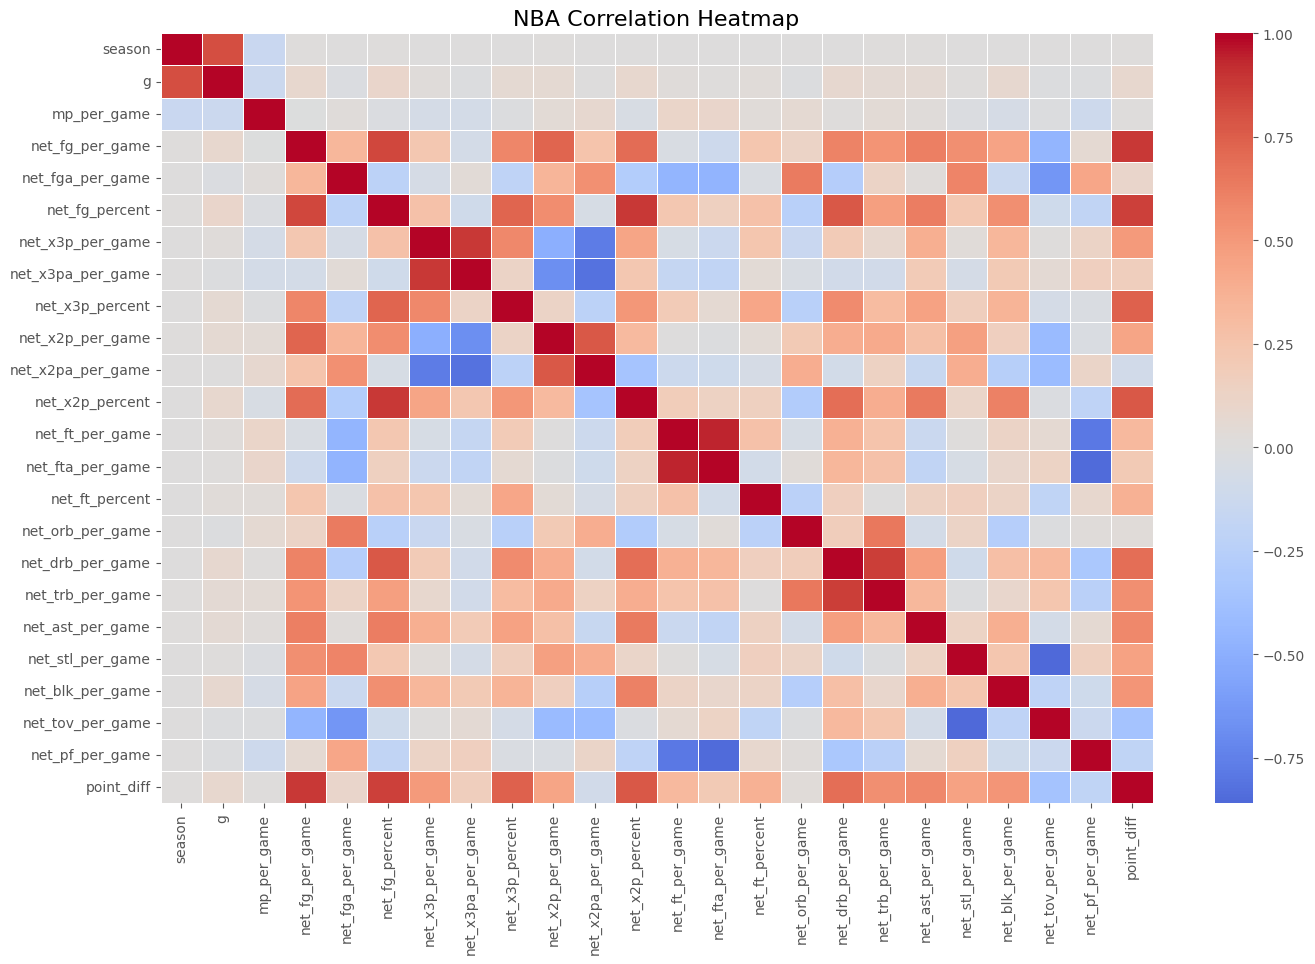

In [863]:
numeric_df = era_20_26.select_dtypes(include=['number'])
corr_matrix_20toPresent = numeric_df.corr()
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix_20toPresent, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('NBA Correlation Heatmap', fontsize=16)
plt.show()

In [864]:
target_corr = corr_matrix_20toPresent['point_diff'].sort_values(ascending=False)
print("Numerical Correlation")
print(target_corr)

Numerical Correlation
point_diff           1.000000
net_fg_per_game      0.883138
net_fg_percent       0.859004
net_x2p_percent      0.781212
net_x3p_percent      0.742765
net_drb_per_game     0.692937
net_ast_per_game     0.581446
net_trb_per_game     0.549356
net_blk_per_game     0.519971
net_x3p_per_game     0.493805
net_stl_per_game     0.460816
net_x2p_per_game     0.438001
net_ft_percent       0.375101
net_ft_per_game      0.317239
net_fta_per_game     0.203156
net_x3pa_per_game    0.168324
net_fga_per_game     0.095307
g                    0.080067
net_orb_per_game     0.028223
mp_per_game          0.011048
season               0.008281
net_x2pa_per_game   -0.086958
net_pf_per_game     -0.197409
net_tov_per_game    -0.361515
Name: point_diff, dtype: float64


## Skew for All Features
Depending on the ML model we choose, we may have to transform certain features (those with a skew >1 or <-1)

### 1980s to 2000s

In [865]:
skewness_series = era_80_00.select_dtypes(include=['number']).skew().sort_values(ascending=False)

print("Features Skews:")
print(skewness_series)

Features Skews:
mp_per_game          0.648560
net_x3pa_per_game    0.304002
net_fga_per_game     0.275776
net_stl_per_game     0.217514
net_x3p_per_game     0.107500
net_pf_per_game      0.104396
net_orb_per_game     0.047330
net_x2p_per_game     0.047161
net_x2p_percent     -0.020418
net_blk_per_game    -0.025577
net_drb_per_game    -0.064291
net_fg_percent      -0.072188
net_fg_per_game     -0.084794
net_ast_per_game    -0.116357
net_trb_per_game    -0.118826
season              -0.124458
net_ft_per_game     -0.182019
net_fta_per_game    -0.186877
net_x2pa_per_game   -0.204019
net_tov_per_game    -0.214661
net_ft_percent      -0.231165
point_diff          -0.245927
net_x3p_percent     -0.359123
g                   -3.833891
dtype: float64


### 2000s to 2020s

In [866]:
skewness_series = era_00_20.select_dtypes(include=['number']).skew().sort_values(ascending=False)

print("Features Skews:")
print(skewness_series)

Features Skews:
mp_per_game          0.673711
net_ast_per_game     0.333357
net_x3p_per_game     0.322546
net_x3pa_per_game    0.272638
net_x2p_percent      0.201689
net_fta_per_game     0.197544
net_blk_per_game     0.195481
net_ft_per_game      0.132279
net_fg_percent       0.118134
net_drb_per_game     0.057081
net_tov_per_game     0.051419
net_stl_per_game     0.007542
net_x3p_percent     -0.009905
season              -0.012266
net_fga_per_game    -0.052919
net_fg_per_game     -0.172381
point_diff          -0.177997
net_orb_per_game    -0.179286
net_x2p_per_game    -0.183804
net_pf_per_game     -0.195385
net_trb_per_game    -0.202356
net_x2pa_per_game   -0.316128
net_ft_percent      -0.325012
g                   -4.117903
dtype: float64


### 2020s to Present

In [867]:
skewness_series = era_20_26.select_dtypes(include=['number']).skew().sort_values(ascending=False)

print("Features Skews:")
print(skewness_series)

Features Skews:
mp_per_game          0.498524
net_x3p_per_game     0.471735
net_x3pa_per_game    0.464213
net_fga_per_game     0.427108
net_stl_per_game     0.276552
net_orb_per_game     0.192645
net_blk_per_game     0.070461
net_ast_per_game     0.064799
net_x2p_percent      0.046864
net_pf_per_game      0.015373
net_x2p_per_game     0.014719
season               0.000000
net_ft_per_game     -0.038212
net_trb_per_game    -0.040511
net_drb_per_game    -0.045086
net_tov_per_game    -0.075540
net_fta_per_game    -0.083521
net_fg_per_game     -0.086248
net_ft_percent      -0.112978
net_x3p_percent     -0.123912
net_fg_percent      -0.128416
point_diff          -0.318351
net_x2pa_per_game   -0.347278
g                   -0.995818
dtype: float64


## Outliers
Which features we choose will impact how we deal with outliers. If we choose a feature with few outliers, we may keep the outliers since they are insignificant. But if there are more outliers then we may transform or Winsorize the data.

### 1980s to 2000s

In [868]:
numeric_cols = era_80_00.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

minim = Q1 - 1.5 * IQR
maxim = Q3 + 1.5 * IQR

outliers = (numeric_cols < minim) | (numeric_cols > maxim)

outlier_counts = outliers.sum().sort_values(ascending=False)
print("Features with the most outliers:")
print(outlier_counts[outlier_counts > 0])

Features with the most outliers:
net_x3pa_per_game    30
g                    29
net_x3p_per_game     19
net_tov_per_game     11
net_x3p_percent       9
mp_per_game           9
net_stl_per_game      7
net_ft_per_game       6
net_x2p_per_game      5
net_x2pa_per_game     5
net_fga_per_game      4
net_pf_per_game       4
net_fta_per_game      4
net_ft_percent        4
net_orb_per_game      3
net_ast_per_game      2
net_blk_per_game      1
point_diff            1
net_trb_per_game      1
dtype: int64


### 2000s to 2020s

In [869]:
numeric_cols = era_00_20.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

minim = Q1 - 1.5 * IQR
maxim = Q3 + 1.5 * IQR

outliers = (numeric_cols < minim) | (numeric_cols > maxim)

outlier_counts = outliers.sum().sort_values(ascending=False)
print("Features with the most outliers:")
print(outlier_counts[outlier_counts > 0])

Features with the most outliers:
g                    32
net_ast_per_game     10
net_blk_per_game      8
net_pf_per_game       8
mp_per_game           8
net_orb_per_game      7
net_ft_percent        7
net_stl_per_game      6
net_fta_per_game      6
net_x3p_percent       6
net_x2pa_per_game     5
net_x2p_per_game      5
net_x3pa_per_game     5
net_fg_percent        5
net_fga_per_game      5
net_x2p_percent       4
net_x3p_per_game      4
net_trb_per_game      4
net_fg_per_game       3
net_drb_per_game      2
net_ft_per_game       2
point_diff            1
net_tov_per_game      1
dtype: int64


### 2020s to Present

In [870]:
numeric_cols = era_20_26.select_dtypes(include=['number'])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1

minim = Q1 - 1.5 * IQR
maxim = Q3 + 1.5 * IQR

outliers = (numeric_cols < minim) | (numeric_cols > maxim)

outlier_counts = outliers.sum().sort_values(ascending=False)
print("Features with the most outliers:")
print(outlier_counts[outlier_counts > 0])

Features with the most outliers:
net_x3p_per_game     6
net_tov_per_game     4
net_x3pa_per_game    4
net_orb_per_game     3
net_pf_per_game      3
net_blk_per_game     3
net_stl_per_game     3
point_diff           2
net_fga_per_game     2
net_x2pa_per_game    2
net_fg_per_game      1
net_x2p_percent      1
net_ast_per_game     1
net_trb_per_game     1
dtype: int64


# Feature Selection

As discussed in [Walsh and Joshi](https://www.sciencedirect.com/science/article/pii/S266682702400015X) and also mentioned above, we need to select features in a way that avoids multicolinearity.

The following shows which features have a correlation |r| > 0.7 with each other, indicating a risk of multicolinearity.

In [871]:
#Code from Stack Overflow https://stackoverflow.com/questions/34902649/how-do-i-loop-across-a-correlation-matrix-to-only-give-me-pairs-of-correlations

numeric_df = NBA_merged_df.select_dtypes(include=['number'])
corr_matrix_merged = numeric_df.corr()

rows, cols = corr_matrix_00to20.shape
flds = list(corr_matrix_00to20.columns)

corr = corr_matrix_00to20.to_numpy()

for i in range(cols):
    for j in range(i+1, cols):
        if corr[i,j] > 0.7 or corr[i,j] < -0.7:
            print(flds[i], ' ', flds[j], ' ', corr[i,j])

net_fg_per_game   net_fg_percent   0.8234891051417834
net_fg_per_game   net_x2p_percent   0.7355779334104384
net_fg_per_game   net_ast_per_game   0.7111928199649218
net_fg_per_game   point_diff   0.7948371117624761
net_fg_percent   net_x2p_percent   0.9400346740383219
net_fg_percent   net_drb_per_game   0.7554013716554457
net_fg_percent   point_diff   0.8391757688984479
net_x3p_per_game   net_x3pa_per_game   0.9556359885288818
net_x3p_per_game   net_x2pa_per_game   -0.8573129018315498
net_x3pa_per_game   net_x2p_per_game   -0.701984583584527
net_x3pa_per_game   net_x2pa_per_game   -0.8675821893015875
net_x2p_per_game   net_x2pa_per_game   0.7364934947703415
net_x2p_percent   net_drb_per_game   0.7194692461685988
net_x2p_percent   point_diff   0.8382695763446627
net_ft_per_game   net_fta_per_game   0.9386241683414585
net_ft_per_game   net_pf_per_game   -0.8226503497316187
net_fta_per_game   net_pf_per_game   -0.8681497545948414
net_drb_per_game   net_trb_per_game   0.8472084949068495
ne

Before using this dataframe to train our model, we can remove irrelevant features and features that cause leakage as follows:


*   Season - Technically we're not removing this completely since we need this for indexing. But we won't train the model with it, since even if strength changes across seasons, these changes are league-wide, so they won't change point-diff
*   Team Name - Identification
*   Abbreviation - Same as Team Name
*   League - We're only looking at the NBA
*   Games Played - Irrelevant for per-game stats
*   Minutes Played Per Game - Always around 240, no impact on point differential
*   Playoffs - **While highly correlated with point differential, this is target leakage**: A team with a high point differential is stronger, so they will be more likely to make playoffs.
*   Anything having to do with points *directly*. This includes

1. x3p_per_game
2. x2p_per_game
3. fg_per_game
4. ft_per_game
5. The 4 above but with attempts
6. The 4 above but with percents

If we leave these included, then the models will pretty much be learning the equation
x3p + x2p + ft

Which is not a very valuable ML result.

(More formally, these features are structural leakage. They are in a direct relationship with the target variable)

In [872]:
#Set season as index so SULOV doesn't remove it and it's not trained
NBA_merged_df = NBA_merged_df.set_index('season')

In [873]:

#Deep copy of dataframe before removing features, can be used to analyze later
no_engineering_df = NBA_merged_df.copy(deep=True)

cols_to_include = ['net_orb_per_game', 'net_drb_per_game', 'net_trb_per_game', 'net_ast_per_game', 'net_stl_per_game', 'net_blk_per_game', 'net_tov_per_game', 'net_blk_per_game', 'net_pf_per_game', 'point_diff']

for col in NBA_merged_df.columns:
  if(col not in cols_to_include):
    NBA_merged_df = NBA_merged_df.drop(columns=col)
    unseen_df = unseen_df.drop(columns=col)

print(NBA_merged_df.columns)
print(no_engineering_df.columns)

Index(['net_orb_per_game', 'net_drb_per_game', 'net_trb_per_game',
       'net_ast_per_game', 'net_stl_per_game', 'net_blk_per_game',
       'net_tov_per_game', 'net_pf_per_game', 'point_diff'],
      dtype='object')
Index(['lg', 'team', 'abbreviation', 'playoffs', 'g', 'mp_per_game',
       'net_fg_per_game', 'net_fga_per_game', 'net_fg_percent',
       'net_x3p_per_game', 'net_x3pa_per_game', 'net_x3p_percent',
       'net_x2p_per_game', 'net_x2pa_per_game', 'net_x2p_percent',
       'net_ft_per_game', 'net_fta_per_game', 'net_ft_percent',
       'net_orb_per_game', 'net_drb_per_game', 'net_trb_per_game',
       'net_ast_per_game', 'net_stl_per_game', 'net_blk_per_game',
       'net_tov_per_game', 'net_pf_per_game', 'point_diff'],
      dtype='object')


In [874]:
NBA_merged_df.head()

,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
season,,,,,,,,,
1980,1.3,0.8,2.1,1.9,1.2,-0.2,-2.0,1.5,2.9
1980,0.8,2.0,2.7,4.0,1.5,-1.3,-1.1,-1.0,7.8
1980,-0.5,1.5,1.0,0.5,-1.7,-1.3,1.7,-0.7,-2.7
1980,0.9,-3.2,-2.2,-1.2,0.7,-1.8,-3.6,-1.2,0.3
1980,1.4,-0.7,0.7,-2.5,-0.8,-0.6,1.2,-1.4,-4.4


###Data Splitting and SULOV

First, we split our data into training and test

In [875]:
X = NBA_merged_df.drop(columns=['point_diff'])
y = NBA_merged_df['point_diff']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
training_df = pd.DataFrame(X_train, columns=X_train.columns)
training_df['point_diff'] = y_train.values

Then, we can use the Featurewiz package's SULOV in order to pick only the most feature with the highest correlation with point_diff from each group of highly correlated features.

############################################################################################
############       F A S T   F E A T U R E  E N G G    A N D    S E L E C T I O N ! ########
# Be judicious with featurewiz. Don't use it to create too many un-interpretable features! #
############################################################################################
featurewiz has selected 0.7 as the correlation limit. Change this limit to fit your needs...
    Skipping feature engineering since no feature_engg input...
Skipping category encoding since no category encoders specified in input...
    Single_Label Regression problem 
    Loaded train data. Shape = (1027, 9)
    Single_Label Regression problem 
No test data filename given...
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#########################################################################

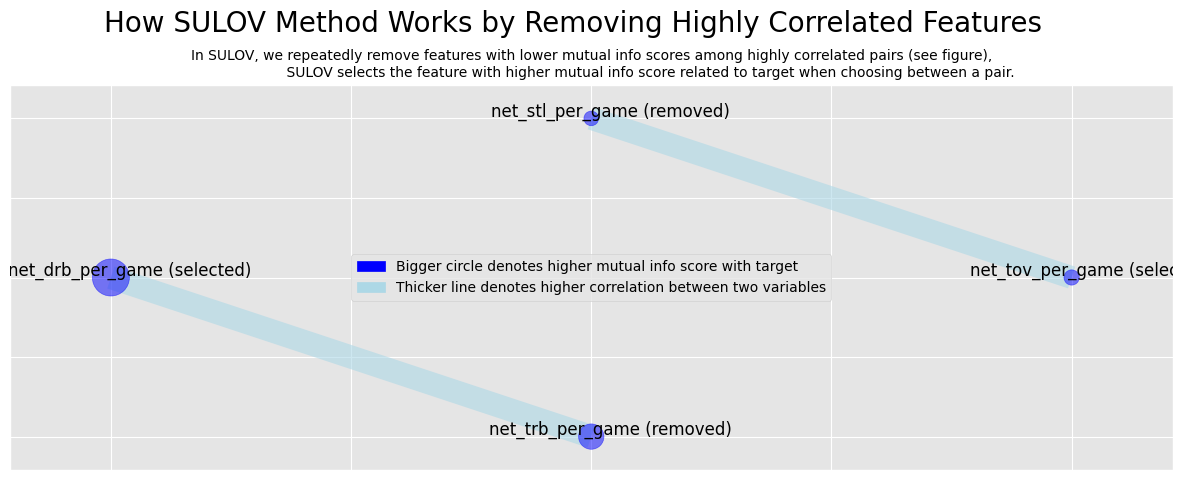

Time taken for SULOV method = 0 seconds
    Adding 0 categorical variables to reduced numeric variables  of 6
Final list of selected 6 vars after SULOV = ['net_orb_per_game', 'net_ast_per_game', 'net_blk_per_game', 'net_pf_per_game', 'net_drb_per_game', 'net_tov_per_game']
Converting all features to numeric before sending to XGBoost...
Skipping Recursive XGBoost method. Continuing ...
#######################################################################################
#####          F E A T U R E   S E L E C T I O N   C O M P L E T E D            #######
#######################################################################################
Selected 6 important features:
['net_orb_per_game', 'net_ast_per_game', 'net_blk_per_game', 'net_pf_per_game', 'net_drb_per_game', 'net_tov_per_game']
Total Time taken for featurewiz selection = 0 seconds
Output contains a list of 6 important features and a train dataframe


In [876]:
import featurewiz as fwiz

outputs = fwiz.featurewiz(dataname=training_df, target="point_diff", corr_limit=0.70, verbose=2, sep=',',
		header=0, test_data='',feature_engg='', category_encoders='',
		dask_xgboost_flag=False, nrows=None, skip_sulov=False, skip_xgboost=True)

Next, we can normalize the features that were chosen using Z-score scaling

In [877]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import make_column_transformer

input_features = NBA_merged_df.columns[:-1]
#scaler = make_column_transformer((StandardScaler(), input_features), remainder='passthrough')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)

scaled_X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
scaled_X_test_df = pd.DataFrame(X_test_scaled, columns=X.columns)



scaled_NBA_merged_df = pd.DataFrame(X_scaled, columns=X.columns)
scaled_NBA_merged_df['point_diff'] = y.values

scaled_unseen_df = pd.DataFrame(scaler.transform(unseen_df[X.columns]), columns=X.columns)
scaled_unseen_df['point_diff'] = unseen_df['point_diff']



In [878]:
scaled_NBA_merged_df.head()

,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
0,0.866297,0.361475,0.762188,0.763638,1.114178,-0.197647,-1.311542,0.892887,2.9
1,0.534076,0.923456,0.982428,1.622717,1.393652,-1.144160,-0.723439,-0.588526,7.8
2,-0.329697,0.689297,0.358416,0.190920,-1.587407,-1.144160,1.106218,-0.410757,-2.7
3,0.600520,-1.511793,-0.816194,-0.504525,0.648388,-1.574393,-2.357061,-0.707039,0.3
4,0.932741,-0.341000,0.248296,-1.036335,-0.748984,-0.541834,0.779494,-0.825553,-4.4


In [879]:
scaled_unseen_df.head()

,net_orb_per_game,net_drb_per_game,net_trb_per_game,net_ast_per_game,net_stl_per_game,net_blk_per_game,net_tov_per_game,net_pf_per_game,point_diff
0,-0.794806,-1.090308,-1.293379,1.336357,0.555230,-0.369741,-0.919473,0.715117,-0.5
1,0.932741,1.157614,1.422906,-0.259074,1.393652,1.007005,-0.462059,0.655861,7.5
2,0.534076,-1.699120,-1.036433,-0.872701,-1.214774,-0.713927,1.106218,0.418835,-8.6
3,1.730070,2.094248,2.597516,-0.054531,-1.587407,-0.111601,2.086392,-0.588526,-4.8
4,-0.529030,0.080485,-0.228889,0.109103,-1.307932,-0.455787,1.563632,0.063295,3.0


### Models before Feature Selection
We can train models on ALL of the features, before we used SULOV, for comparison's sake

In [880]:
from sklearn.model_selection import cross_val_score, KFold
#Use KFold to split into training and test


[0.91832051 0.93013454 0.8851338  0.87238444 0.87089736]
Index(['net_orb_per_game', 'net_drb_per_game', 'net_trb_per_game',
       'net_ast_per_game', 'net_stl_per_game', 'net_blk_per_game',
       'net_tov_per_game', 'net_pf_per_game'],
      dtype='object')
MSE: 2.364414212150106, R2: 0.8895744279547119


<Axes: xlabel='y', ylabel='y_pred'>

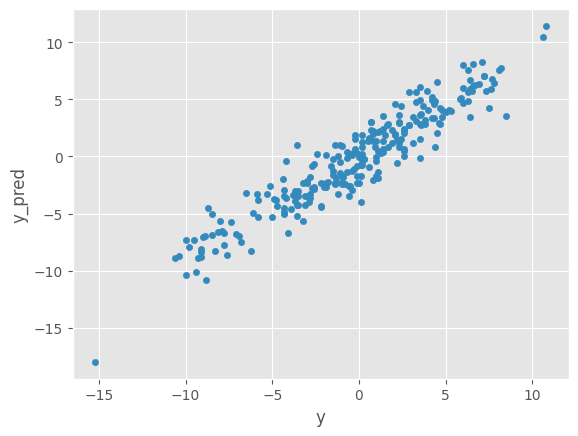

In [881]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
scores = cross_val_score(model, X, y, cv=5, scoring = 'r2')
print(scores)
print(scaled_X_train_df.columns)
model.fit(scaled_X_train_df, y_train)

#Got this from HW1

y_pred = model.predict(scaled_X_test_df)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("MSE: {}, R2: {}".format(mse, r2))
df = pd.DataFrame({
    'y': y_test,
    'y_pred': y_pred
})
df.plot.scatter(x='y', y = 'y_pred', title='LinearReg Pre-SULOV')

In [882]:
coefficients_df = pd.DataFrame({
    'Feature' : scaled_X_train_df.columns,
    'Coefficient' : model.coef_
})
print(coefficients_df)

            Feature  Coefficient
0  net_orb_per_game    -1.874709
1  net_drb_per_game     1.630475
2  net_trb_per_game     2.680506
3  net_ast_per_game     0.676273
4  net_stl_per_game     0.107878
5  net_blk_per_game     0.221669
6  net_tov_per_game    -2.734465
7   net_pf_per_game    -0.462806


In [883]:
#Change dataframe to only contain the selected features
selected_df = scaled_NBA_merged_df.copy(deep=True)
for col in selected_df.columns:
  if(col not in outputs[0]):
    selected_df = selected_df.drop(columns=col)
    if(col in scaled_X_train_df.columns):
      scaled_X_train_df = scaled_X_train_df.drop(columns=col)
      scaled_X_test_df = scaled_X_test_df.drop(columns=col)
    if (col in scaled_unseen_df.columns and col != 'point_diff'): scaled_unseen_df = scaled_unseen_df.drop(columns=col)



#print(scaled_X_train_df)



# Model Training (SULOV-selected features)

With the features selected, we can begin training our models.

TODO: Analysis of each of these results

## Linear Regression

[0.91831894 0.93014413 0.88512728 0.87239045 0.87093711]
Train MSE: 2.1374967052904705, Train R2: 0.9027949232953044
Test MSE: 2.395230418208191, Test R2: 0.888135214315772


<Axes: xlabel='y', ylabel='y_pred'>

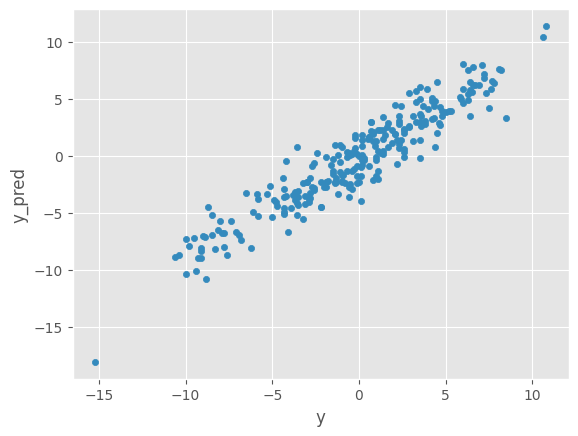

In [884]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import joblib



linearModel = LinearRegression(fit_intercept=False)
scores = cross_val_score(linearModel, X, y, cv=5, scoring = 'r2')
print(scores)

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
linearModel.fit(scaled_X_train_df, y_train)

# save the model
joblib.dump(linearModel, 'LinRegModel.joblib')

#Training Scores
y_train_pred = linearModel.predict(scaled_X_train_df)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("Train MSE: {}, Train R2: {}".format(train_mse, train_r2))

#Got this from HW1
y_pred = linearModel.predict(scaled_X_test_df)


#Test scores
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Test MSE: {}, Test R2: {}".format(mse, r2))
df = pd.DataFrame({
    'y': y_test,
    'y_pred': y_pred
})
df.plot.scatter(x='y', y = 'y_pred', title='LinearReg Post-SULOV')

In [885]:
coefficients_df = pd.DataFrame({
    'Feature' : scaled_X_train_df.columns,
    'Coefficient' : linearModel.coef_
})
print(coefficients_df)

            Feature  Coefficient
0  net_orb_per_game    -0.390366
1  net_drb_per_game     3.768215
2  net_ast_per_game     0.661909
3  net_blk_per_game     0.219314
4  net_tov_per_game    -2.839264
5   net_pf_per_game    -0.448076


### Test Linear Model on unseen data


<Axes: title={'center': 'LinearReg Post-SULOV Unseen Data'}, xlabel='y', ylabel='y_pred'>

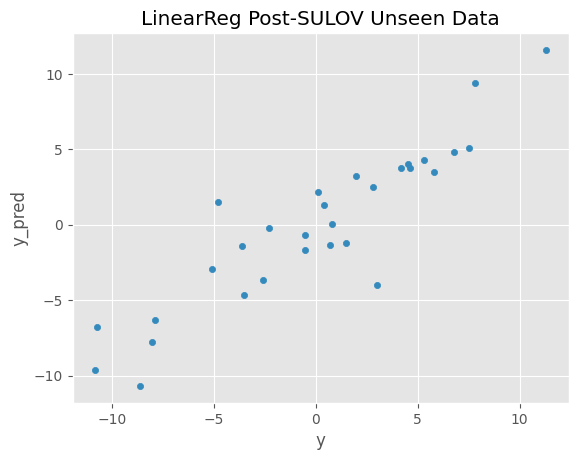

In [891]:
X_unseen = scaled_unseen_df[outputs[0]]
X_unseen = X_unseen[scaled_X_train_df.columns]
y_unseen = scaled_unseen_df['point_diff']
y_pred_lin_unseen = linearModel.predict(X_unseen)
df = pd.DataFrame({
    'y': y_unseen,
    'y_pred': y_pred_lin_unseen
})
df.plot.scatter(x='y', y = 'y_pred', title='LinearReg Post-SULOV Unseen Data')

## Random Forest

Train MSE: 1.7361225501173774, Train R2: 0.9210478663030369
Test MSE: 3.4732353706740167, Test R2: 0.8377889962411299


<Axes: title={'center': 'Random Forest Post-SULOV'}, xlabel='y', ylabel='y_pred'>

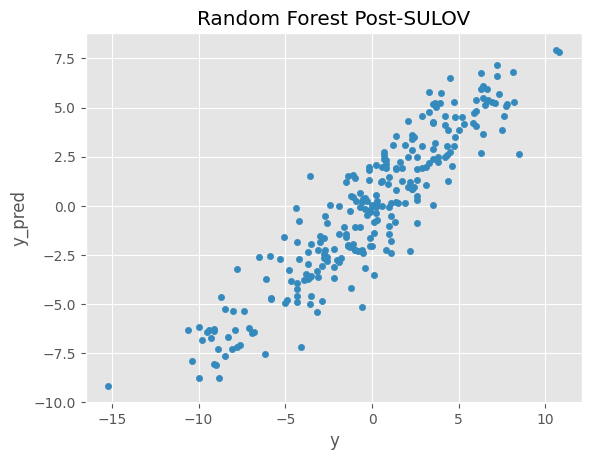

In [892]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'max_depth' : [2, 3, 4, 5, 10],
    'min_samples_split' : [3, 5, 10],
    'max_features' : [2,3,4],
    'min_samples_leaf': [2, 3, 5],
    'n_estimators' : [10, 50, 100]
}

forestModel = RandomForestRegressor(random_state=0)
grid_search = RandomizedSearchCV(estimator = forestModel, param_distributions = param_distributions, cv = 5)
#scores = cross_val_score(grid_search, X, y, cv=5, scoring = 'r2')
#print(scores)

forestModel = grid_search.fit(scaled_X_train_df, y_train)

# save the model
joblib.dump(forestModel, 'RandForestModel.joblib')

#Training Scores
y_train_pred = forestModel.predict(scaled_X_train_df)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("Train MSE: {}, Train R2: {}".format(train_mse, train_r2))

#Got this from HW1
y_pred = forestModel.predict(scaled_X_test_df)


#Test scores
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Test MSE: {}, Test R2: {}".format(mse, r2))
df = pd.DataFrame({
    'y': y_test,
    'y_pred': y_pred
})
df.plot.scatter(x='y', y = 'y_pred', title='Random Forest Post-SULOV')


### Test `forestModel` with Unseen Data

<Axes: title={'center': 'Random Forest Post-SULOV Unseen Data'}, xlabel='y', ylabel='y_pred'>

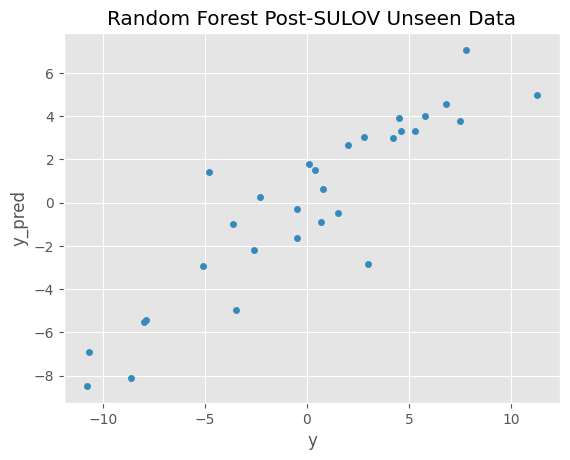

In [893]:
X_unseen = scaled_unseen_df[outputs[0]]
X_unseen = X_unseen[scaled_X_train_df.columns]
y_unseen = scaled_unseen_df['point_diff']
y_pred_for_unseen = forestModel.predict(X_unseen)
df = pd.DataFrame({
    'y': y_unseen,
    'y_pred': y_pred_for_unseen
})
df.plot.scatter(x='y', y = 'y_pred', title='Random Forest Post-SULOV Unseen Data')

## Ridge Regression

We already did feature selection, so Ridge regression can be used to reduce overfitting. If we didn't do feature selection beforehand, we could have used Lasso regression to do feature selection automatically



[0.91869313 0.93027992 0.88544766 0.8726963  0.87048116]
Optimal alpha = 0.1
Train MSE: 2.1344169303519234, Train R2: 0.9029349795388504
Test MSE: 2.3904014414527373, Test R2: 0.888360742701566


<Axes: title={'center': 'RidgeReg Post-SULOV'}, xlabel='y', ylabel='y_pred'>

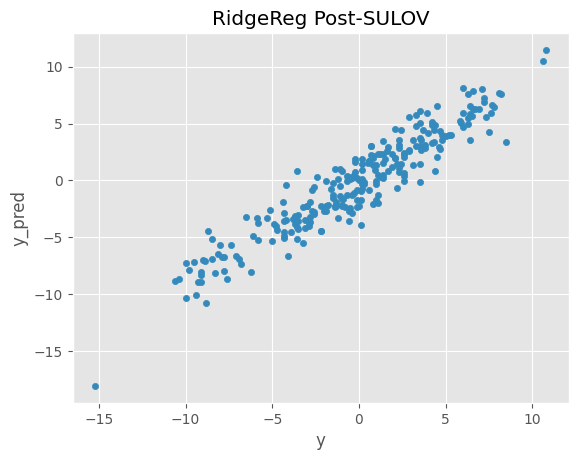

In [894]:
from sklearn.linear_model import Ridge, RidgeCV

alphas = [1e-2, 1e-1, 1, 5, 10, 100]

ridgeModel = RidgeCV(alphas = alphas, store_cv_values = True)
scores = cross_val_score(ridgeModel, X, y, cv=5, scoring = 'r2')
print(scores)

ridgeModel.fit(scaled_X_train_df, y_train)
print(f"Optimal alpha = {ridgeModel.alpha_}")
# save the model
joblib.dump(ridgeModel, 'RidgeRegModel.joblib')

#Training Scores
y_train_pred = ridgeModel.predict(scaled_X_train_df)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)
print("Train MSE: {}, Train R2: {}".format(train_mse, train_r2))

#Got this from HW1
y_pred = ridgeModel.predict(scaled_X_test_df)


#Test scores
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Test MSE: {}, Test R2: {}".format(mse, r2))
df = pd.DataFrame({
    'y': y_test,
    'y_pred': y_pred
})
df.plot.scatter(x='y', y = 'y_pred', title='RidgeReg Post-SULOV')

Note: The R2 and MSE scores are actually worse in Ridge than in the standard Linear Regression for alpha = 1

TODO: Use RidgeCV to find optimal alpha value



### Test RidgeModel on unseen data

<Axes: title={'center': 'RidgeReg Post-SULOV Unseen Data'}, xlabel='y', ylabel='y_pred'>

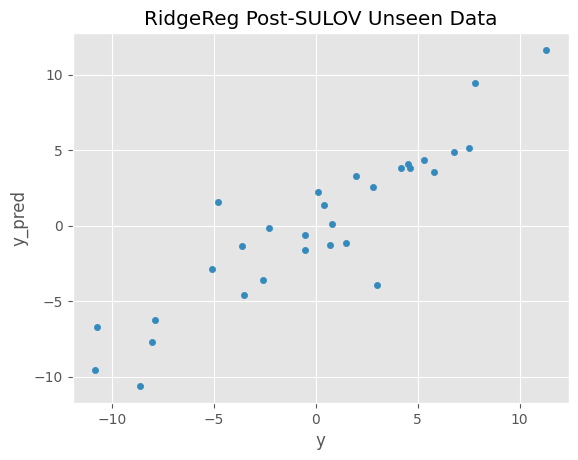

In [895]:
X_unseen = scaled_unseen_df[outputs[0]]
X_unseen = X_unseen[scaled_X_train_df.columns]
y_unseen = scaled_unseen_df['point_diff']
y_pred_rid_unseen = ridgeModel.predict(X_unseen)
df = pd.DataFrame({
    'y': y_unseen,
    'y_pred': y_pred_rid_unseen
})
df.plot.scatter(x='y', y = 'y_pred', title='RidgeReg Post-SULOV Unseen Data')

### Model Training (Hand-Picked Features)

